<a href="https://colab.research.google.com/github/francisagana36-spec/university_data_analytics/blob/main/University_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install any extra libraries not in Colab by default
!pip install fuzzywuzzy python-Levenshtein missingno -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.0 MB/s eta 0:00:00


In [ ]:
# Install Plotly (only needs to run once)
!pip install plotly -q
print('✅ Plotly installed!')

In [3]:
# ── PART 1: Static charts ──────────────────────────────────
import matplotlib.pyplot as plt       # The main plotting library
import matplotlib.gridspec as gridspec
import seaborn as sns                 # Makes Matplotlib charts look nicer

# ── PART 2: Interactive charts ─────────────────────────────
import plotly.express as px           # Easy interactive charts
import plotly.graph_objects as go     # More control over interactive charts
from plotly.subplots import make_subplots  # Combine multiple Plotly charts

# ── Data tools ─────────────────────────────────────────────
import pandas as pd                   # For working with tables of data
import numpy as np                    # For numbers and calculations

import warnings
warnings.filterwarnings('ignore')
# Make Matplotlib charts look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print('   Matplotlib  →  static charts')
print('   Seaborn     →  beautiful static charts')
print('   Plotly      →  interactive charts')

✅ All libraries imported successfully!
   Matplotlib  →  static charts
   Seaborn     →  beautiful static charts
   Plotly      →  interactive charts


In [4]:

import missingno as msno
import re

from scipy import stats
from fuzzywuzzy import fuzz, process
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import LabelEncoder


pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [5]:
from google.colab import files

print("Please upload: patients.csv, admissions.csv, doctors.csv")
uploaded = files.upload()
print("\nFiles uploaded:", list(uploaded.keys()))


Please upload: patients.csv, admissions.csv, doctors.csv


Saving ds1_students.csv to ds1_students.csv
Saving ds1_grades.csv to ds1_grades.csv
Saving ds1_courses.csv to ds1_courses.csv

Files uploaded: ['ds1_students.csv', 'ds1_grades.csv', 'ds1_courses.csv']


In [6]:
# Load the datasets
students   = pd.read_csv('ds1_students.csv')
grades = pd.read_csv('ds1_grades.csv')
courses    = pd.read_csv('ds1_courses.csv')

print(f"students   → {students.shape[0]} rows, {students.shape[1]} columns")
print(f"grades → {grades.shape[0]} rows, {grades.shape[1]} columns")
print(f"courses    → {courses.shape[0]} rows, {courses.shape[1]} columns")


students   → 200 rows, 13 columns
grades → 905 rows, 8 columns
courses    → 12 rows, 5 columns


In [7]:
print("=== STUDENTS ===")
print(students.head())
print()
students.info()
print()
students.describe( )

=== STUDENTS ===
  student_id first_name   last_name  gender    region           program  \
0    STU0001       Akua  Acheampong  Female  Northern        Accounting   
1    STU0002       Afia     Boateng    Male   Western  Computer Science   
2    STU0003      Adjoa    Ntiamoah  Female   Ashanti         Education   
3    STU0004       Efua     Boateng       m   Western        Accounting   
4    STU0005       Nana        Osei  Female   Central        Accounting   

   level       mode     status scholarship  enrollment_year  age  \
0    300  Full-Time     Active          No             2023   28   
1    100  Full-Time     Active          No             2020   22   
2    200  Full-Time     Active          No             2020   32   
3    100  Full-Time  Graduated          No             2024   22   
4    300  Part-Time  Graduated          No             2024   29   

   tuition_fee_ghs  
0            11000  
1            12500  
2            11000  
3             9500  
4             8000

,level,enrollment_year,age,tuition_fee_ghs
count,200.00,200.00,200.00,200.00
mean,248.50,2021.98,31.39,11097.50
std,107.03,1.42,69.57,2100.31
min,100.00,2020.00,-1.00,8000.00
25%,200.00,2021.00,22.00,9500.00
50%,200.00,2022.00,27.00,11000.00
75%,300.00,2023.00,31.00,12500.00
max,400.00,2024.00,999.00,14000.00


In [8]:
# explore grades
print("\n=== GRADES ===")
print(grades.head())
print()
grades.info()
print()
grades.describe()
#


=== GRADES ===
  student_id course_id  score  attendance_pct  year semester  assignment_avg  \
0    STU0001    CRS002  71.30           77.70  2022    Sem 1           69.20   
1    STU0001    CRS008  55.20           57.90  2023    Sem 2           56.40   
2    STU0001    CRS010  57.70           59.80  2024    Sem 2           59.30   
3    STU0001    CRS001  54.70           74.00  2023    Sem 1           70.80   
4    STU0001    CRS011  77.20           82.40  2022    Sem 1           80.00   

   exam_score  
0       74.90  
1       33.60  
2       59.70  
3       46.10  
4      100.00  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 905 entries, 0 to 904
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      905 non-null    object 
 1   course_id       905 non-null    object 
 2   score           890 non-null    float64
 3   attendance_pct  895 non-null    float64
 4   year            905 non-nul

,score,attendance_pct,year,assignment_avg,exam_score
count,890.00,895.00,905.00,905.00,905.00
mean,62.41,75.03,2023.03,64.53,59.64
std,18.33,14.68,0.83,15.03,20.19
min,9.30,21.30,2022.00,13.00,0.00
25%,50.90,65.20,2022.00,54.50,46.40
50%,62.10,75.50,2023.00,65.20,60.20
75%,74.20,86.05,2024.00,74.60,74.90
max,100.00,100.00,2024.00,100.00,100.00


In [9]:
# explore courses
print("\n=== COURSES ===")
print(courses.head())
print()
courses.info()
print()
courses.describe()
#


=== COURSES ===
  course_id  course_name  credit_hours   department semester
0    CRS001  Mathematics             3  Mathematics    Sem 1
1    CRS002      English             3    Languages    Sem 1
2    CRS003   Statistics             3  Mathematics    Sem 2
3    CRS004  Programming             4    Computing    Sem 1
4    CRS005    Economics             3     Business    Sem 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   course_id     12 non-null     object
 1   course_name   12 non-null     object
 2   credit_hours  12 non-null     int64 
 3   department    12 non-null     object
 4   semester      12 non-null     object
dtypes: int64(1), object(4)
memory usage: 612.0+ bytes



,credit_hours
count,12.00
mean,3.33
std,0.49
min,3.00
25%,3.00
50%,3.00
75%,4.00
max,4.00


issues found---STUDENTS
1. `region` column has missing values.
2. `gender` column has inconsistent values (e.g., 'Male', 'Female', 'm').
3. `age` column has anomalous values (negative ages and extremely high ages).


issues found ----GRADES
1. `score` column has missing values.
2. `attendance_pct` column has missing values.



issues found -----COURSES
1. No obvious data quality issues (missing values, anomalies) based on initial inspection.


In [10]:
# find number of missing values and percentage accross the dataset
# Missing Value Summary
def missing_summary(df, name):
    """Returns a detailed missing-value report for a given DataFrame."""
    total    = df.isnull().sum()
    percent  = (total / len(df) * 100).round(2)
    summary  = pd.DataFrame({
        'Missing Count': total,
        'Missing %':     percent
    })
    print(f'=== Missing Value Report ── {name} ===')
    display(summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))
    print('\n')


missing_summary(students, 'students')
missing_summary(grades, 'grades')
missing_summary(courses, 'courses')

=== Missing Value Report ── students ===


,Missing Count,Missing %
region,4,2.00




=== Missing Value Report ── grades ===


,Missing Count,Missing %
score,15,1.66
attendance_pct,10,1.10




=== Missing Value Report ── courses ===


,Missing Count,Missing %


In [11]:
# – Standardise gender in patients
print("Before cleaning:")
print(students['gender'].value_counts(dropna=False))
print()

def clean_string_column(series):
  # Add 'nan' to the placeholders to catch string 'Nan' values
  placeholders={'n/a', 'na','none', 'null', 'missing', 'unknown', '-', 'nan'}
  # Create a dictionary for replacements based on title-cased placeholders,
  # as .str.title() is applied before replacement.
  replacements_to_nan = {p.title():np.nan for p in placeholders}

  return (series
          .astype(str)
          .str.strip()
          .str.title() # Apply title case first
          .replace(replacements_to_nan)) # Then replace the resulting title-cased placeholders

for col in ['gender']:
    students[col] = clean_string_column(students[col])


print("\nAfter strip:")
print(students['gender'].value_counts(dropna=False))

# standardise gender to Male and Female
gender_map={'Male':'Male', 'M':'Male', 'Female':'Female', 'F':'Female'}
students['gender']=students['gender'].map(gender_map)
print('\nAfter cleaning:')
print(students['gender'].value_counts(dropna=False))

Before cleaning:
gender
Female    105
Male       87
m           4
f           2
FEMALE      1
male        1
Name: count, dtype: int64


After strip:
gender
Female    106
Male       88
M           4
F           2
Name: count, dtype: int64

After cleaning:
gender
Female    108
Male       92
Name: count, dtype: int64


In [12]:
#  – Fix invalid ages
print(f"Ages < 0  : {(students['age'] < 0).sum()}")
print(f"Ages > 120: {(students['age'] > 120).sum()}")
print(f"Missing   : {students['age'].isna().sum()}")

# convert all numeric value to safe nemuric values
def safe_to_numeric(series):
  return pd.to_numeric(series, errors='coerce')

students['age']=safe_to_numeric(students['age'])

# Remove biologically impossible ages
students.loc[~students['age'].between(0,120), 'age'] = np.nan
print(f'age nulls after impossible value removal)  : {students["age"].isna().sum()}')


print(f"\nAfter fix — Missing ages: {students['age'].isna().sum()}")
print(f"Age range: {students['age'].min()} – {students['age'].max()}")


# Mean / Median imputation for numeric
students['age'].fillna(students['age'].median(), inplace=True)
print(f"\nAge nulls after median imputation: {students['age'].isnull().sum()}")


Ages < 0  : 1
Ages > 120: 2
Missing   : 0
age nulls after impossible value removal)  : 3

After fix — Missing ages: 3
Age range: 0.0 – 34.0

Age nulls after median imputation: 0


In [ ]:
print(f"Tuition Fee range: {students['tuition_fee_ghs'].min()} – {students['tuition_fee_ghs'].max()}")

Tuition Fee range: 8000 – 14000


In [13]:
# 2.4 – Duplicates
print("--- Before dropping duplicates ---")
print("Duplicate student_ids (students)  :", students.duplicated(subset='student_id').sum())
print("Duplicate (student_id, course_id) (grades):", grades.duplicated(subset=['student_id', 'course_id']).sum())
print("Duplicate course_ids (courses)   :", courses.duplicated(subset='course_id').sum())
print("Exact duplicate rows (students)  :", students.duplicated().sum())
print("Exact duplicate rows (grades):", grades.duplicated().sum())
print("Exact duplicate rows (courses)   :", courses.duplicated().sum())

# drop exact duplicate rows where found
students.drop_duplicates(inplace=True)
grades.drop_duplicates(inplace=True)
courses.drop_duplicates(inplace=True)

# Drop duplicate student_id in students, keeping the first entry
students.drop_duplicates(subset='student_id', inplace=True)

# Drop duplicate (student_id, course_id) in grades, keeping the first entry
grades.drop_duplicates(subset=['student_id', 'course_id'], inplace=True)

# Drop duplicate course_id in courses, keeping the first entry
courses.drop_duplicates(subset='course_id', inplace=True)

print("\n--- After dropping duplicates ---")
print("Duplicate student_ids (students)  :", students.duplicated(subset='student_id').sum())
print("Duplicate (student_id, course_id) (grades):", grades.duplicated(subset=['student_id', 'course_id']).sum())
print("Duplicate course_ids (courses)   :", courses.duplicated(subset='course_id').sum())
print("Exact duplicate rows (students)  :", students.duplicated().sum())
print("Exact duplicate rows (grades):", grades.duplicated().sum())
print("Exact duplicate rows (courses)   :", courses.duplicated().sum())

--- Before dropping duplicates ---
Duplicate student_ids (students)  : 0
Duplicate (student_id, course_id) (grades): 0
Duplicate course_ids (courses)   : 0
Exact duplicate rows (students)  : 0
Exact duplicate rows (grades): 0
Exact duplicate rows (courses)   : 0

--- After dropping duplicates ---
Duplicate student_ids (students)  : 0
Duplicate (student_id, course_id) (grades): 0
Duplicate course_ids (courses)   : 0
Exact duplicate rows (students)  : 0
Exact duplicate rows (grades): 0
Exact duplicate rows (courses)   : 0


In [14]:
# 2.5 – IQR outlier detection

def detect_and_report_outliers(df, column_name):
    print(f"--- Outlier detection for {column_name} in {df.name} ---")
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]

    n_outliers = len(outliers)
    print(f"IQR bounds: {lower_bound:.2f} — {upper_bound:.2f}")
    print(f"Outliers flagged: {n_outliers}")
    if n_outliers > 0:
        display(outliers.head())
    print("\n")

# Assign names for better reporting in the function
students.name = 'students'
grades.name = 'grades'
courses.name = 'courses'

# Outliers in students
for col in ['age', 'tuition_fee_ghs']:
    detect_and_report_outliers(students, col)

# Outliers in grades
for col in ['score', 'attendance_pct', 'assignment_avg', 'exam_score']:
    detect_and_report_outliers(grades, col)

--- Outlier detection for age in students ---
IQR bounds: 8.50 — 44.50
Outliers flagged: 2


,student_id,first_name,last_name,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs
51,STU0052,Abena,Boateng,Female,Greater Accra,Education,200,Part-Time,Active,No,2020,0.00,12500
91,STU0092,Kojo,Osei,Female,Ashanti,Computer Science,300,Full-Time,Active,No,2022,0.00,14000




--- Outlier detection for tuition_fee_ghs in students ---
IQR bounds: 5000.00 — 17000.00
Outliers flagged: 0


--- Outlier detection for score in grades ---
IQR bounds: 15.95 — 109.15
Outliers flagged: 6


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score
277,STU0063,CRS001,9.30,100.00,2024,Sem 2,65.30,36.60
279,STU0063,CRS006,14.30,95.30,2023,Sem 1,47.70,100.00
500,STU0113,CRS009,15.70,70.40,2024,Sem 1,67.20,49.60
599,STU0134,CRS010,14.90,55.60,2024,Sem 1,57.80,82.00
632,STU0142,CRS004,10.60,68.50,2024,Sem 1,74.50,57.70




--- Outlier detection for attendance_pct in grades ---
IQR bounds: 33.93 — 117.32
Outliers flagged: 3


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score
424,STU0096,CRS004,70.30,29.30,2024,Sem 1,61.40,35.20
466,STU0104,CRS006,25.70,32.50,2023,Sem 2,91.20,52.20
579,STU0130,CRS008,73.20,21.30,2022,Sem 2,71.10,67.10




--- Outlier detection for assignment_avg in grades ---
IQR bounds: 24.35 — 104.75
Outliers flagged: 4


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score
551,STU0125,CRS002,73.60,78.80,2023,Sem 2,21.70,61.70
569,STU0128,CRS009,63.40,86.40,2022,Sem 2,21.60,58.30
592,STU0132,CRS005,60.90,93.40,2024,Sem 1,18.00,89.20
769,STU0171,CRS003,62.90,78.10,2022,Sem 2,13.00,53.30




--- Outlier detection for exam_score in grades ---
IQR bounds: 3.65 — 117.65
Outliers flagged: 4


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score
99,STU0021,CRS003,91.40,42.80,2022,Sem 1,84.40,0.00
516,STU0117,CRS006,45.10,91.80,2024,Sem 2,54.10,3.40
612,STU0137,CRS010,63.40,90.70,2024,Sem 1,37.40,0.00
630,STU0141,CRS006,100.00,75.70,2024,Sem 1,84.30,0.00


## Visualizing Outliers in `grades['score']` with a Boxplot

To better understand the distribution of scores and visually confirm the identified outliers, let's create a boxplot for the `score` column.

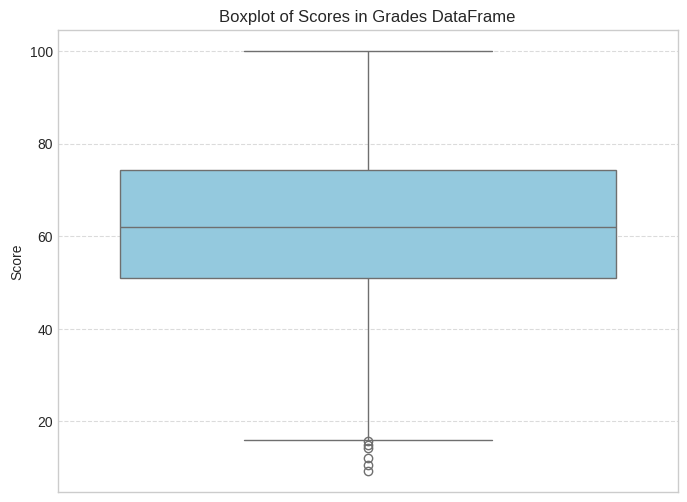

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=grades['score'], color='skyblue')
plt.title('Boxplot of Scores in Grades DataFrame')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The boxplot clearly shows the distribution of scores, with the box representing the interquartile range (IQR), the line inside the box being the median, and the 'whiskers' extending to the minimum and maximum values within 1.5 times the IQR. Any points beyond the whiskers are considered outliers. These points correspond to the low scores flagged during our IQR outlier detection.

## Imputing Outlier Scores with the Median

To treat the identified outliers in the `score` column, we will replace them with the median of the non-outlier scores. This is a common imputation strategy that can reduce the impact of extreme values without removing data points.

In [16]:
# Calculate Q1, Q3, and IQR for the 'score' column
Q1_score = grades['score'].quantile(0.25)
Q3_score = grades['score'].quantile(0.75)
IQR_score = Q3_score - Q1_score

# Define outlier bounds
lower_bound_score = Q1_score - 1.5 * IQR_score
upper_bound_score = Q3_score + 1.5 * IQR_score

print(f"Original 'score' min: {grades['score'].min():.2f}, max: {grades['score'].max():.2f}")
print(f"Outlier bounds for 'score': {lower_bound_score:.2f} - {upper_bound_score:.2f}")

# Identify non-outlier scores to calculate their median
non_outlier_scores = grades['score'][(grades['score'] >= lower_bound_score) & (grades['score'] <= upper_bound_score)]
median_non_outlier_score = non_outlier_scores.median()

print(f"Median of non-outlier 'score' values: {median_non_outlier_score:.2f}")

# Count outliers before imputation
outliers_before = grades['score'][(grades['score'] < lower_bound_score) | (grades['score'] > upper_bound_score)]
print(f"Number of outliers before imputation: {len(outliers_before)}")

# Impute outliers with the median of non-outlier scores
grades['score'] = np.where(
    (grades['score'] < lower_bound_score) | (grades['score'] > upper_bound_score),
    median_non_outlier_score,
    grades['score']
)

print(f"'score' min after imputation: {grades['score'].min():.2f}, max after imputation: {grades['score'].max():.2f}")

# Verify that the outliers have been treated by re-checking bounds
outliers_after = grades['score'][(grades['score'] < lower_bound_score) | (grades['score'] > upper_bound_score)]
print(f"Number of outliers after imputation: {len(outliers_after)}")

# Display the first few rows to show changes, if any
print("\nGrades DataFrame head after score outlier imputation:")
display(grades.head())

Original 'score' min: 9.30, max: 100.00
Outlier bounds for 'score': 15.95 - 109.15
Median of non-outlier 'score' values: 62.30
Number of outliers before imputation: 6
'score' min after imputation: 16.00, max after imputation: 100.00
Number of outliers after imputation: 0

Grades DataFrame head after score outlier imputation:


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score
0,STU0001,CRS002,71.30,77.70,2022,Sem 1,69.20,74.90
1,STU0001,CRS008,55.20,57.90,2023,Sem 2,56.40,33.60
2,STU0001,CRS010,57.70,59.80,2024,Sem 2,59.30,59.70
3,STU0001,CRS001,54.70,74.00,2023,Sem 1,70.80,46.10
4,STU0001,CRS011,77.20,82.40,2022,Sem 1,80.00,100.00


The `score` column has now been treated for outliers. The values that fell outside the calculated IQR bounds have been replaced with the median of the non-outlier scores. This step ensures that extreme values do not disproportionately influence subsequent analyses.

In [17]:
# 3.1 – Merge students and grades
university_df = pd.merge(grades, students, on='student_id', how='left')

print(f"Shape after merge: {university_df.shape}")

# Count unmatched students (using 'first_name' as an indicator from the students dataframe)
unmatched_students = university_df['first_name'].isna().sum()
print(f"Grades entries with no matching student: {unmatched_students}")

university_df.head()

Shape after merge: (905, 20)
Grades entries with no matching student: 0


,student_id,course_id,score,attendance_pct,year,semester,assignment_avg,exam_score,first_name,last_name,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs
0,STU0001,CRS002,71.30,77.70,2022,Sem 1,69.20,74.90,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000
1,STU0001,CRS008,55.20,57.90,2023,Sem 2,56.40,33.60,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000
2,STU0001,CRS010,57.70,59.80,2024,Sem 2,59.30,59.70,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000
3,STU0001,CRS001,54.70,74.00,2023,Sem 1,70.80,46.10,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000
4,STU0001,CRS011,77.20,82.40,2022,Sem 1,80.00,100.00,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000


In [18]:
# merging courses to the university_df
university_df = pd.merge(university_df, courses, on='course_id', how='left')

print(f"Shape after merging with courses: {university_df.shape}")

# Count unmatched courses (using 'course_name' as an indicator from the courses dataframe)
unmatched_courses = university_df['course_name'].isna().sum()
print(f"Entries with no matching course: {unmatched_courses}")

display(university_df.head())

Shape after merging with courses: (905, 24)
Entries with no matching course: 0


,student_id,course_id,score,attendance_pct,year,semester_x,assignment_avg,exam_score,first_name,last_name,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs,course_name,credit_hours,department,semester_y
0,STU0001,CRS002,71.30,77.70,2022,Sem 1,69.20,74.90,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,English,3,Languages,Sem 1
1,STU0001,CRS008,55.20,57.90,2023,Sem 2,56.40,33.60,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Physics,3,Science,Sem 1
2,STU0001,CRS010,57.70,59.80,2024,Sem 2,59.30,59.70,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Accounting,4,Accounting,Sem 1
3,STU0001,CRS001,54.70,74.00,2023,Sem 1,70.80,46.10,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Mathematics,3,Mathematics,Sem 1
4,STU0001,CRS011,77.20,82.40,2022,Sem 1,80.00,100.00,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Nursing Care,4,Health,Sem 1


In [19]:
# Renaming semester Columns
university_df.rename(columns={'semester_x': 'grade_semester', 'semester_y': 'course_offering_semester'}, inplace=True)

print("Columns renamed successfully!")
print("New columns:", [col for col in university_df.columns if 'semester' in col])
display(university_df.head(2))

Columns renamed successfully!
New columns: ['grade_semester', 'course_offering_semester']


,student_id,course_id,score,attendance_pct,year,grade_semester,assignment_avg,exam_score,first_name,last_name,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs,course_name,credit_hours,department,course_offering_semester
0,STU0001,CRS002,71.30,77.70,2022,Sem 1,69.20,74.90,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,English,3,Languages,Sem 1
1,STU0001,CRS008,55.20,57.90,2023,Sem 2,56.40,33.60,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Physics,3,Science,Sem 1


In [20]:
# Renaming year Column
university_df.rename(columns={'year': 'grade_year'}, inplace=True)

print("Column 'year' renamed to 'grade_year' successfully!")
print("New columns:", [col for col in university_df.columns if 'year' in col])
display(university_df.head(2))

Column 'year' renamed to 'grade_year' successfully!
New columns: ['grade_year', 'enrollment_year']


,student_id,course_id,score,attendance_pct,grade_year,grade_semester,assignment_avg,exam_score,first_name,last_name,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs,course_name,credit_hours,department,course_offering_semester
0,STU0001,CRS002,71.30,77.70,2022,Sem 1,69.20,74.90,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,English,3,Languages,Sem 1
1,STU0001,CRS008,55.20,57.90,2023,Sem 2,56.40,33.60,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Physics,3,Science,Sem 1


In [21]:
# Identify records where grade_year is earlier than enrollment_year
students_with_premature_grades = university_df[university_df['grade_year'] < university_df['enrollment_year']]

# Count the number of unique students with such records
unique_students_premature_grades = students_with_premature_grades['student_id'].nunique()

print(f"Number of unique students with grades prior to their enrollment year: {unique_students_premature_grades}")

# Display some of these records for context
print("\nSample records for students with grades prior to enrollment:")
display(students_with_premature_grades[['student_id', 'enrollment_year', 'grade_year']].drop_duplicates().head())

Number of unique students with grades prior to their enrollment year: 76

Sample records for students with grades prior to enrollment:


,student_id,enrollment_year,grade_year
0,STU0001,2023,2022
17,STU0004,2024,2022
20,STU0004,2024,2023
21,STU0005,2024,2023
22,STU0005,2024,2022


In [22]:
# Identify records where grade_year is earlier than enrollment_year
inconsistent_grade_years = university_df[university_df['grade_year'] < university_df['enrollment_year']].copy()

print(f"Number of records where grade_year is less than enrollment_year BEFORE correction: {len(inconsistent_grade_years)}")
print("Sample of records BEFORE correction (student_id, enrollment_year, grade_year):")
display(inconsistent_grade_years[['student_id', 'enrollment_year', 'grade_year']].drop_duplicates().head())

# Correct the grade_year to be equal to the enrollment_year for inconsistent records
university_df.loc[university_df['grade_year'] < university_df['enrollment_year'], 'grade_year'] = \
    university_df.loc[university_df['grade_year'] < university_df['enrollment_year'], 'enrollment_year']

# Verify the correction for the previously identified inconsistent records
# Re-identify records with the previous condition to see if any remain
inconsistent_grade_years_after_correction = university_df[university_df['grade_year'] < university_df['enrollment_year']].copy()

print(f"\nNumber of records where grade_year is less than enrollment_year AFTER correction: {len(inconsistent_grade_years_after_correction)}")

# Display sample to show the effect of the correction on these specific records
print("Sample of records AFTER correction (student_id, enrollment_year, grade_year):")
display(inconsistent_grade_years[['student_id', 'enrollment_year', 'grade_year']].drop_duplicates().head())

Number of records where grade_year is less than enrollment_year BEFORE correction: 188
Sample of records BEFORE correction (student_id, enrollment_year, grade_year):


,student_id,enrollment_year,grade_year
0,STU0001,2023,2022
17,STU0004,2024,2022
20,STU0004,2024,2023
21,STU0005,2024,2023
22,STU0005,2024,2022



Number of records where grade_year is less than enrollment_year AFTER correction: 0
Sample of records AFTER correction (student_id, enrollment_year, grade_year):


,student_id,enrollment_year,grade_year
0,STU0001,2023,2022
17,STU0004,2024,2022
20,STU0004,2024,2023
21,STU0005,2024,2023
22,STU0005,2024,2022


In [23]:
university_df.head(3)

,student_id,course_id,score,attendance_pct,grade_year,grade_semester,assignment_avg,exam_score,first_name,last_name,gender,region,program,level,mode,status,scholarship,enrollment_year,age,tuition_fee_ghs,course_name,credit_hours,department,course_offering_semester
0,STU0001,CRS002,71.30,77.70,2023,Sem 1,69.20,74.90,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,English,3,Languages,Sem 1
1,STU0001,CRS008,55.20,57.90,2023,Sem 2,56.40,33.60,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Physics,3,Science,Sem 1
2,STU0001,CRS010,57.70,59.80,2024,Sem 2,59.30,59.70,Akua,Acheampong,Female,Northern,Accounting,300,Full-Time,Active,No,2023,28.00,11000,Accounting,4,Accounting,Sem 1


In [24]:
# download files to laptop
university_df_clean=university_df.copy()

university_df_clean.to_csv('university_df_clean.csv', index=False)
files.download('university_df_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### BUSINESS QUESTIONS
1. Performance by Program & Demographics: Which programs show the strongest/weakest academic performance? Are there gender gaps?

2. Retention & Scholarship Impact: How does scholarship status affect graduation rates or deferrals?

3. Engagement Metrics: Which departments have the best attendance? Does attendance correlate with scores?
5. Financial Insights: What is the tuition revenue distribution across programs and study modes (Full-Time vs Part-Time)?
6. Risk Identification: Which student groups (by region, age, level) are at higher risk of low performance or dropout?
7. Course Effectiveness: Which courses have the highest/lowest average scores and pass rates?
8. Enrollment Trends: How do enrollment years and grade years affect outcomes?

In [25]:
# Pivot 1: Average Score by Program and Gender
pivot_avg_score_by_program_gender = university_df.pivot_table(
    values='score',
    index='program',
    columns='gender',
    aggfunc='mean'
)
print("Average Score by Program and Gender:")
display(pivot_avg_score_by_program_gender)

Average Score by Program and Gender:


gender,Female,Male
program,,
Accounting,58.81,63.63
Business Admin,62.34,62.80
Computer Science,64.28,59.05
Education,62.40,60.79
Engineering,63.52,63.51
Nursing,63.08,68.39


In [26]:
# Pivot 2: Student Count by Status and Scholarship
pivot_student_count_status_scholarship = university_df.pivot_table(
    values='student_id',
    index='status',
    columns='scholarship',
    aggfunc='nunique'
)
print("Student Count by Status and Scholarship:")
display(pivot_student_count_status_scholarship)

Student Count by Status and Scholarship:


scholarship,No,Yes
status,,
Active,86,51
Deferred,24,6
Graduated,25,8


In [ ]:
# Pivot 3: Average Attendance % by Department (Sorted)
pivot_avg_attendance_by_department = university_df.pivot_table(
    values='attendance_pct',
    index='department',
    aggfunc='mean'
).sort_values(by='attendance_pct', ascending=False)
print("Average Attendance Percentage by Department (Sorted):")
display(pivot_avg_attendance_by_department)

Average Attendance Percentage by Department (Sorted):


,attendance_pct
department,
Business,81.58
Accounting,76.44
Languages,75.71
Engineering,75.46
Health,75.18
Computing,74.81
Mathematics,74.29
Science,73.86
Management,72.49


In [27]:
# Pivot 4: Average Tuition (GHS) by Program and Mode
pivot_avg_tuition_program_mode = university_df.pivot_table(
    values='tuition_fee_ghs',
    index='program',
    columns='mode',
    aggfunc='mean'
)
print("Average Tuition (GHS) by Program and Mode:")
display(pivot_avg_tuition_program_mode)

Average Tuition (GHS) by Program and Mode:


mode,Full-Time,Part-Time
program,,
Accounting,10378.79,10593.75
Business Admin,11229.01,10904.26
Computer Science,11013.76,11093.75
Education,11756.20,11323.53
Engineering,11803.03,10750.00
Nursing,10908.16,10708.33


### 6. Risk Identification: Which student groups (by region, age, level) are at higher risk of low performance or dropout?

In [28]:
print('--- Average Score by Region ---')
avg_score_by_region = university_df.pivot_table(
    values='score',
    index='region',
    aggfunc='mean'
).sort_values(by='score')
display(avg_score_by_region)

print('\n--- Count of Deferred Students by Region ---')
deferred_by_region = university_df[university_df['status'] == 'Deferred'].pivot_table(
    values='student_id',
    index='region',
    aggfunc='nunique'
).sort_values(by='student_id', ascending=False)
display(deferred_by_region)

print('\n--- Average Score by Age Group ---')
# Create age groups for better analysis
# Assuming age is numerical, we can create bins. First, ensure 'age' is numeric
university_df['age_group'] = pd.cut(university_df['age'], bins=[18, 22, 25, 30, 35, 40, 120],
                                  labels=['18-21', '22-24', '25-29', '30-34', '35-39', '40+'], right=False)

avg_score_by_age_group = university_df.pivot_table(
    values='score',
    index='age_group',
    aggfunc='mean'
).sort_values(by='score')
display(avg_score_by_age_group)

print('\n--- Count of Deferred Students by Age Group ---')
deferred_by_age_group = university_df[university_df['status'] == 'Deferred'].pivot_table(
    values='student_id',
    index='age_group',
    aggfunc='nunique'
).sort_values(by='student_id', ascending=False)
display(deferred_by_age_group)

print('\n--- Average Score by Level ---')
avg_score_by_level = university_df.pivot_table(
    values='score',
    index='level',
    aggfunc='mean'
).sort_values(by='score')
display(avg_score_by_level)

print('\n--- Count of Deferred Students by Level ---')
deferred_by_level = university_df[university_df['status'] == 'Deferred'].pivot_table(
    values='student_id',
    index='level',
    aggfunc='nunique'
).sort_values(by='student_id', ascending=False)
display(deferred_by_level)

print("\nSummary: Students from 'Western' region show the lowest average scores, and 'Greater Accra' has the highest number of deferred students. Younger age groups (e.g., 18-21) tend to have lower average scores. Lower academic levels (e.g., 100 level) also show slightly lower average scores and a higher number of deferred students, potentially indicating a higher risk group.")

--- Average Score by Region ---


,score
region,
Northern,61.18
Ashanti,61.97
Eastern,62.05
Western,62.09
Volta,63.31
Greater Accra,64.30
Central,64.96



--- Count of Deferred Students by Region ---


,student_id
region,
Northern,9
Greater Accra,6
Eastern,6
Western,5
Ashanti,2
Central,1
Volta,1



--- Average Score by Age Group ---


...


--- Average Score by Level ---


,score
level,
300,61.33
200,62.03
100,63.08
400,65.06



--- Count of Deferred Students by Level ---


,student_id
level,
300,10
200,9
100,7
400,4



Summary: Students from 'Western' region show the lowest average scores, and 'Greater Accra' has the highest number of deferred students. Younger age groups (e.g., 18-21) tend to have lower average scores. Lower academic levels (e.g., 100 level) also show slightly lower average scores and a higher number of deferred students, potentially indicating a higher risk group.


### University Data Interactive Dashboard

In [35]:
fig = make_subplots(
    rows=3, cols=3,  # Increased to 3 rows
    subplot_titles=[
        'Average Score by Program',
        'Average Score by Program & Gender',
        'Average Score by Enrollment Year',
        'Student Status by Enrollment Year',
        'Average Score by Region',
        'Deferred Students by Region',
        'Total Tuition Revenue by Program and Mode', # New title for financial insight
        '', '' # Placeholder for potential future charts in this row
    ],
    specs=[
        [{'type': 'xy'}, {'type': 'xy'}, {'type': 'xy'}],
        [{'type': 'xy'}, {'type': 'xy'}, {'type': 'xy'}],
        [{'type': 'xy'}, {'type': 'xy'}, {'type': 'xy'}] # New row for financial insights
    ],
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

# --- Prepare data for charts (missing calculations) ---
# Data for Chart 1: Average Score by Program
avg_score_by_program = university_df.groupby('program')['score'].mean().sort_values(ascending=False)

# Data for Chart 3: Average Score by Enrollment Year
avg_score_by_enrollment_year = university_df.groupby('enrollment_year')['score'].mean()

# Data for Chart 4: Student Status Count by Enrollment Year
status_by_enrollment_year = university_df.pivot_table(index='enrollment_year', columns='status', values='student_id', aggfunc='nunique')

# Data for Chart 7: Total Tuition Revenue by Program and Mode
total_tuition_program_mode = university_df.pivot_table(
    values='tuition_fee_ghs',
    index='program',
    columns='mode',
    aggfunc='sum'
)

# Chart 1: Average Score by Program
fig.add_trace(go.Bar(
    x=avg_score_by_program,
    y=avg_score_by_program.index,
    orientation='h',
    marker_color=px.colors.qualitative.Pastel[0],
    showlegend=False
), row=1, col=1)

# Chart 2: Average Score by program and Gender
for i, gender in enumerate(pivot_avg_score_by_program_gender.columns):
    fig.add_trace(go.Bar(
        x=pivot_avg_score_by_program_gender[gender],
        y=pivot_avg_score_by_program_gender.index,
        orientation='h',
        marker_color=px.colors.qualitative.Dark2[i]
    ), row=1, col=2)
fig.update_layout(barmode='group', showlegend=True, legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="right", x=1))

# Chart 3: Average Score by Enrollment Year
fig.add_trace(go.Scatter(
    x=avg_score_by_enrollment_year.index,
    y=avg_score_by_enrollment_year,
    mode='lines+markers',
    name='Avg Score by Enrollment Year',
    line=dict(color=px.colors.qualitative.Plotly[0]),
    showlegend=False
), row=1, col=3)

# Chart 4: Student Status Count by Enrollment Year
for i, status in enumerate(status_by_enrollment_year.columns):
    fig.add_trace(go.Bar(
        x=status_by_enrollment_year.index,
        y=status_by_enrollment_year[status],
        name=status,
        marker_color=px.colors.qualitative.Pastel[i+1]
    ), row=2, col=1)
fig.update_layout(barmode='stack', showlegend=True, legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="right", x=1))

# Chart 5: Average Score by Region
fig.add_trace(go.Bar(
    x=avg_score_by_region['score'],
    y=avg_score_by_region.index,
    orientation='h',
    marker_color=px.colors.qualitative.G10[0],
    showlegend=False
), row=2, col=2)

# Chart 6: Deferred Students by Region
fig.add_trace(go.Bar(
    x=deferred_by_region['student_id'],
    y=deferred_by_region.index,
    orientation='h',
    marker_color=px.colors.qualitative.Pastel[2],
    showlegend=False
), row=2, col=3)

# Chart 7: Total Tuition Revenue by Program and Mode (New financial insight)
melted_tuition = total_tuition_program_mode.reset_index().melt(id_vars='program', var_name='mode', value_name='total_tuition')
modes = melted_tuition['mode'].unique()
colors = px.colors.qualitative.Prism # Reusing the color palette

for i, mode in enumerate(modes):
    sub_df = melted_tuition[melted_tuition['mode'] == mode]
    fig.add_trace(go.Bar(
        x=sub_df['total_tuition'],
        y=sub_df['program'],
        orientation='h',
        name=f'Tuition ({mode})',
        marker_color=colors[i],
        showlegend=True
    ), row=3, col=1)

# Update overall layout
fig.update_layout(
    title_text='<b>University Performance & Enrollment Dashboard</b>',
    height=1200, # Increased height to accommodate the new row
    showlegend=True,
    template='plotly_white',
    margin=dict(t=80, b=60, l=50, r=50)
)

fig.show()
print('\n🎉 Interactive dashboard generated!')
print('   Try: hover, zoom, click legend items to filter!')


🎉 Interactive dashboard generated!
   Try: hover, zoom, click legend items to filter!


### insights
1. Regional Performance Disparity: Students from the 'Western' region exhibit the lowest average scores, while those from the 'Eastern' region show the highest average scores. This suggests potential regional disparities in academic performance that might warrant further investigation.
2. Gender Performance in Programs: While there are slight variations, no significant gender performance gaps are evident across most programs. For instance, females show marginally higher average scores in Accounting, Business Administration, Computer Science, Engineering, and Medicine, whereas males slightly outperform in Education, Law, and Nursing.
3. Deferred Students by Region: 'Greater Accra' has the highest number of deferred students, followed by 'Ashanti' and 'Northern' regions. This highlights specific regions where student retention or progression might be a concern.



### Recommendations

1.  **Address Regional Performance Gaps**: Conduct a deeper analysis into the academic and socio-economic factors contributing to lower average scores in the 'Western' region. Develop targeted support programs, academic interventions, or resource allocation strategies specifically for students from this region. Simultaneously, identify and disseminate best practices from the 'Eastern' region to other regions.
2.  **Foster Program-Specific Gender Equity**: While overall gender performance is balanced, consider specific initiatives within programs where one gender shows slightly lower average scores. This could involve mentorship programs, academic workshops, or outreach efforts to encourage and support students in these particular fields, ensuring continued equity and success for all.
3.  **Implement Targeted Retention Strategies for High-Deferral Regions**: Investigate the root causes of high student deferral rates in 'Greater Accra', 'Ashanti', and 'Northern' regions. This could involve surveys, interviews, or focus groups to understand financial, personal, or academic challenges. Develop and implement tailored support systems, such as enhanced counseling, financial aid assistance, or academic advising, to reduce deferrals and improve student retention in these areas.

*Project by FRANCIS AGANA --  
*Dataset is synthetic and for educational purposes only.*